# Entregable 1: Importación de Librerías, Configuración del Entorno y Carga de Datos

En este primer paso cargamos todas las librerías necesarias para el procesamiento de datos, visualización y construcción de modelos de Machine Learning en Google Colab. Además, fijamos la semilla aleatoria (`SEED = 42`) para garantizar que los experimentos sean reproducibles y habilitamos la carga directa del archivo `Churn_Modelling.csv`.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Configuración de semilla de reproducibilidad
SEED = 42
np.random.seed(SEED)

print("Google Drive montado con éxito y semilla configurada.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive montado con éxito y semilla configurada.


# Entregable 2: Carga del Dataset desde Google Drive y Exploración Inicial (EDA - Parte 1)

Cargamos el dataset `Churn_Modelling.csv` Desplegamos las dimensiones del archivo, visualizamos las primeras filas para verificar su formato y revisamos los tipos de datos junto con la presencia de valores nulos.

In [4]:
# Carga de datos
df = pd.read_csv("/content/drive/MyDrive/Algoritmos de AA/CSV/Churn_Modelling.csv")

# Visualización inicial
print("Dimensiones del conjunto de datos (filas, columnas):", df.shape)
print("\nPrimeras 5 filas del dataset:")
display(df.head())

print("\nInformación general y verificación de valores nulos:")
print(df.info())

Dimensiones del conjunto de datos (filas, columnas): (10000, 14)

Primeras 5 filas del dataset:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0



Información general y verificación de valores nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None


# Entregable 3: Limpieza de Datos y Selección de Características

Eliminamos del conjunto de datos las columnas `RowNumber`, `CustomerId` y `Surname`. Estas variables son identificadores únicos o información personal que no aportan valor predictivo para saber si un cliente abandonará el banco y podrían distorsionar el aprendizaje de los modelos.

In [5]:
# Eliminación de columnas no informativas
df_cleaned = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

print("Columnas conservadas para el modelo:")
print(df_cleaned.columns.tolist())

Columnas conservadas para el modelo:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


# Entregable 4: Análisis de la Variable Objetivo y Proporción de Clases (EDA - Parte 2)

Visualizamos la distribución de la variable objetivo `Exited` (0 representa clientes retenidos y 1 representa clientes que abandonaron el banco) para evaluar el nivel de desbalance de clases y calculamos el porcentaje general de tasa de abandono (*Churn Rate*).

/tmp/ipykernel_1067/162459335.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Exited', data=df_cleaned, palette='Set2')


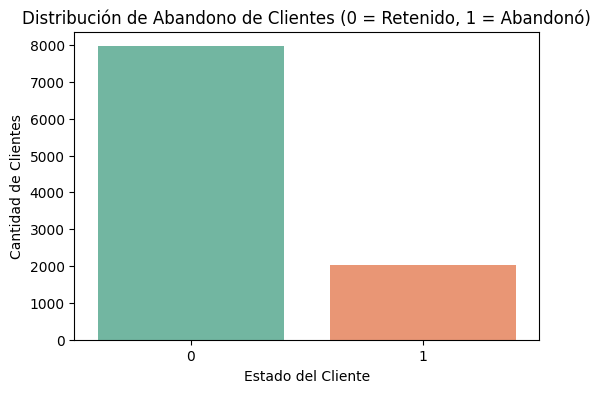

Tasa general de abandono (Churn Rate): 20.37%


In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Exited', data=df_cleaned, palette='Set2')
plt.title('Distribución de Abandono de Clientes (0 = Retenido, 1 = Abandonó)')
plt.xlabel('Estado del Cliente')
plt.ylabel('Cantidad de Clientes')
plt.show()

churn_rate = df_cleaned['Exited'].mean() * 100
print(f"Tasa general de abandono (Churn Rate): {churn_rate:.2f}%")

# Entregable 5: Preprocesamiento de Datos (Codificación y Escalamiento)

Preparamos los datos para los modelos de Machine Learning. Separamos la variable respuesta (`y`) de las características (`X`). Aplicamos `OneHotEncoder` a las variables categóricas (`Geography` y `Gender`) y escalamos las variables numéricas al rango [0, 1] utilizando `MinMaxScaler` con la ayuda de `ColumnTransformer`.

In [7]:
# Separación de características y etiqueta objetivo
X = df_cleaned.drop(columns=['Exited'])
y = df_cleaned['Exited']

# Identificación de tipos de columnas
cat_cols = ['Geography', 'Gender']
num_cols = [col for col in X.columns if col not in cat_cols]

# Construcción del pipeline de preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ]
)

# Aplicación de transformaciones
X_processed = preprocessor.fit_transform(X)
print("Matriz de características procesada con dimensiones:", X_processed.shape)

Matriz de características procesada con dimensiones: (10000, 11)


# Entregable 6: División del Conjunto de Datos (Train / Test Split)

Dividimos los datos procesados en un 80% para entrenamiento de modelos y un 20% para la evaluación final en datos no vistos. Utilizamos el parámetro `stratify=y` para conservar la misma proporción de clases en ambos subconjuntos.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"Número de muestras para entrenamiento: {X_train.shape[0]}")
print(f"Número de muestras para prueba: {X_test.shape[0]}")

Número de muestras para entrenamiento: 8000
Número de muestras para prueba: 2000


# Entregable 7: Entrenamiento y Comparación de Modelos de Clasificación

Entrenamos cuatro algoritmos distintos: Regresión Logística, Máquinas de Vectores de Soporte (SVM), Random Forest y Gradient Boosting. Evaluamos la capacidad discriminativa de cada uno calculando el área bajo la curva ROC (`ROC-AUC Score`).

In [9]:
models = {
    'Regresión Logística': LogisticRegression(random_state=SEED),
    'SVM': SVC(probability=True, random_state=SEED),
    'Random Forest': RandomForestClassifier(random_state=SEED),
    'Gradient Boosting': GradientBoostingClassifier(random_state=SEED)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, y_pred_proba)
    results[name] = auc_score
    print(f"Modelo: {name} | ROC-AUC Score: {auc_score:.4f}")

Modelo: Regresión Logística | ROC-AUC Score: 0.7737
Modelo: SVM | ROC-AUC Score: 0.8152
Modelo: Random Forest | ROC-AUC Score: 0.8523
Modelo: Gradient Boosting | ROC-AUC Score: 0.8708


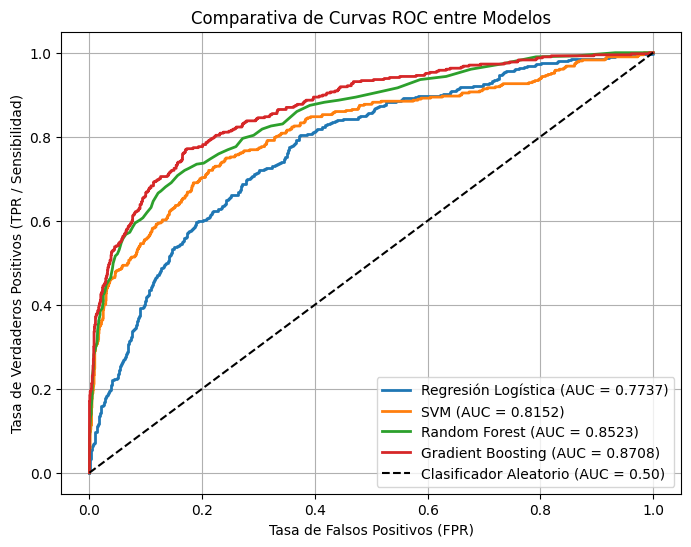

In [11]:
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc_val = roc_auc_score(y_test, y_pred_proba)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc_val:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio (AUC = 0.50)')
plt.title('Comparativa de Curvas ROC entre Modelos')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR / Sensibilidad)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Entregable 8: Evaluación Final, Matriz de Confusión y Ajuste de Umbral

Tomamos el mejor modelo (Gradient Boosting) y ajustamos el umbral de decisión a `0.35` para optimizar la sensibilidad (*Recall*) sobre la clase de riesgo (clientes que se van del banco). Mostramos la matriz de confusión detallada y el reporte de métricas clave (Precision, Recall y F1-Score).

--- Reporte de Clasificación (Umbral = 0.35) ---
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      1593
           1       0.67      0.60      0.63       407

    accuracy                           0.86      2000
   macro avg       0.78      0.76      0.77      2000
weighted avg       0.85      0.86      0.85      2000



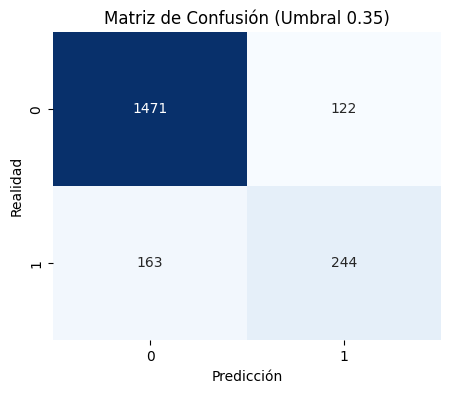

In [10]:
best_model = models['Gradient Boosting']
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

# Ajuste de umbral optimizado para retención
custom_threshold = 0.35
y_pred_custom = (y_pred_proba >= custom_threshold).astype(int)

print(f"--- Reporte de Clasificación (Umbral = {custom_threshold}) ---")
print(classification_report(y_test, y_pred_custom))

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_custom)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Matriz de Confusión (Umbral {custom_threshold})')
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.show()